# ShelfSense M5 — Exploratory Data Analysis

Comprehensive EDA of the M5 Walmart Sales Forecasting dataset.  
Covers data structure, distributions, seasonality, price effects, and hierarchical patterns.

**Dataset:** 30,490 daily time series × 1,941 days | 10 stores | 3 states | 3 categories

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data/raw/m5-forecasting-accuracy'
REPORTS_DIR = '../reports'
os.makedirs(REPORTS_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 3.1 Data Overview

In [2]:
# Load all datasets
print('Loading datasets...')
cal      = pd.read_csv(f'{DATA_DIR}/calendar.csv', parse_dates=['date'])
prices   = pd.read_csv(f'{DATA_DIR}/sell_prices.csv')
train_val = pd.read_csv(f'{DATA_DIR}/sales_train_validation.csv')
train_eval = pd.read_csv(f'{DATA_DIR}/sales_train_evaluation.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print('\n--- SHAPES ---')
for name, df in [('calendar', cal), ('sell_prices', prices),
                  ('train_validation', train_val), ('train_evaluation', train_eval),
                  ('sample_submission', sample_sub)]:
    print(f'  {name:25s}: {df.shape}')

Loading datasets...



--- SHAPES ---
  calendar                 : (1969, 14)
  sell_prices              : (6841121, 4)
  train_validation         : (30490, 1919)
  train_evaluation         : (30490, 1947)
  sample_submission        : (60980, 29)


In [3]:
# Memory usage
print('\n--- MEMORY USAGE ---')
for name, df in [('calendar', cal), ('sell_prices', prices),
                  ('train_validation', train_val), ('train_evaluation', train_eval)]:
    mem = df.memory_usage(deep=True).sum() / 1e6
    print(f'  {name:25s}: {mem:.1f} MB')


--- MEMORY USAGE ---
  calendar                 : 0.6 MB


  sell_prices              : 894.6 MB
  train_validation         : 477.5 MB
  train_evaluation         : 484.3 MB


In [4]:
# Calendar overview
print('--- CALENDAR ---')
print(cal.dtypes)
print(f'\nDate range: {cal.date.min()} → {cal.date.max()}')
print(f'Total days: {len(cal)}')
print(f'\nEvent types:\n{cal["event_type_1"].value_counts(dropna=False).head(10)}')
print(f'\nSNAP columns:\n{cal[["snap_CA", "snap_TX", "snap_WI"]].sum()}')

--- CALENDAR ---
date            datetime64[ns]
wm_yr_wk                 int64
weekday                 object
wday                     int64
month                    int64
year                     int64
d                       object
event_name_1            object
event_type_1            object
event_name_2            object
event_type_2            object
snap_CA                  int64
snap_TX                  int64
snap_WI                  int64
dtype: object

Date range: 2011-01-29 00:00:00 → 2016-06-19 00:00:00
Total days: 1969

Event types:
event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

SNAP columns:
snap_CA    650
snap_TX    650
snap_WI    650
dtype: int64


In [5]:
# Hierarchical structure
print('--- HIERARCHICAL STRUCTURE ---')
print(f'Unique states      : {train_val.state_id.nunique()} → {sorted(train_val.state_id.unique())}')
print(f'Unique stores      : {train_val.store_id.nunique()} → {sorted(train_val.store_id.unique())}')
print(f'Unique categories  : {train_val.cat_id.nunique()} → {sorted(train_val.cat_id.unique())}')
print(f'Unique departments : {train_val.dept_id.nunique()} → {sorted(train_val.dept_id.unique())}')
print(f'Unique items       : {train_val.item_id.nunique()}')
print(f'Total series       : {len(train_val)}')

--- HIERARCHICAL STRUCTURE ---
Unique states      : 3 → ['CA', 'TX', 'WI']
Unique stores      : 10 → ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Unique categories  : 3 → ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Unique departments : 7 → ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Unique items       : 3049
Total series       : 30490


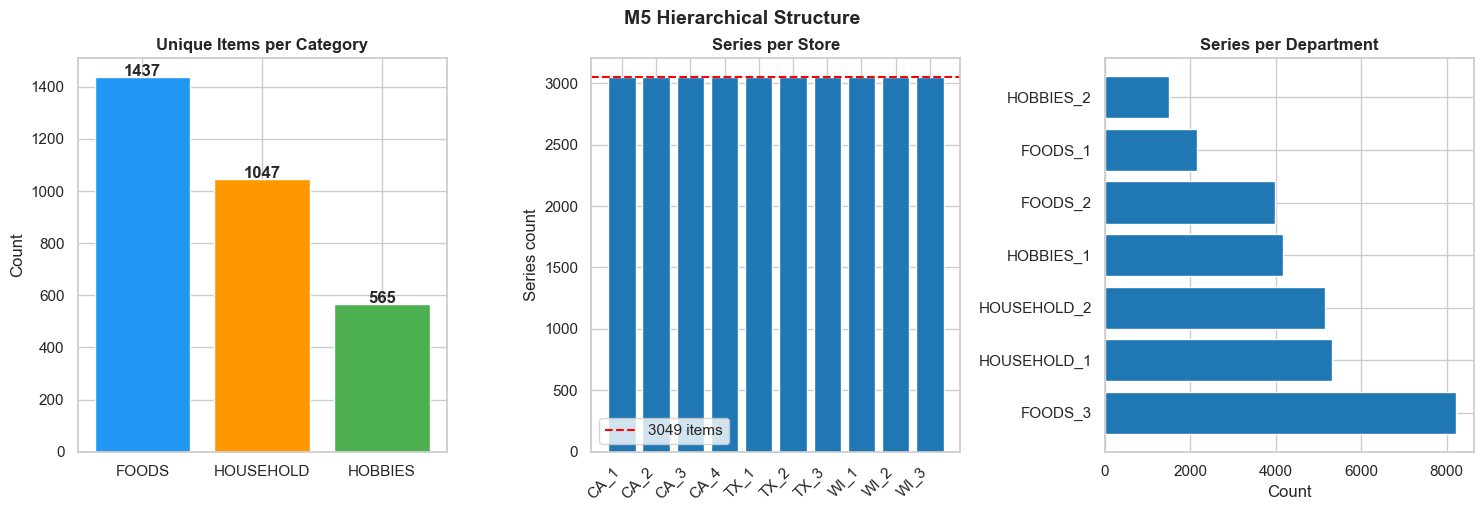

In [6]:
# Hierarchy visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Items per category
cat_counts = train_val.groupby('cat_id')['item_id'].nunique().sort_values(ascending=False)
axes[0].bar(cat_counts.index, cat_counts.values, color=['#2196F3','#FF9800','#4CAF50'])
axes[0].set_title('Unique Items per Category', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Series per store
store_counts = train_val['store_id'].value_counts().sort_index()
axes[1].bar(range(len(store_counts)), store_counts.values)
axes[1].set_xticks(range(len(store_counts)))
axes[1].set_xticklabels(store_counts.index, rotation=45, ha='right')
axes[1].set_title('Series per Store', fontweight='bold')
axes[1].set_ylabel('Series count')
axes[1].axhline(3049, color='red', linestyle='--', label='3049 items')
axes[1].legend()

# Series per dept
dept_counts = train_val['dept_id'].value_counts().sort_values(ascending=False)
axes[2].barh(dept_counts.index, dept_counts.values)
axes[2].set_title('Series per Department', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.suptitle('M5 Hierarchical Structure', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../reports/fig_01_hierarchy.png', bbox_inches='tight', dpi=100)
plt.show()

## 3.2 Sales Distribution

In [7]:
# Extract sales columns and melt to long format for analysis
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in train_eval.columns if c.startswith('d_')]

# Aggregate total daily sales across all series
sales_matrix = train_eval[day_cols].values  # shape: (30490, 1941)
daily_total = sales_matrix.sum(axis=0)      # total sales per day

# Map day index to calendar dates
day_to_date = cal.set_index('d')['date'].to_dict()
dates = [day_to_date.get(d) for d in day_cols]

print(f'Sales matrix: {sales_matrix.shape}')
print(f'Total sales across all history: {sales_matrix.sum():,.0f}')
print(f'Median daily sales per series: {np.median(sales_matrix):.1f}')
print(f'Mean daily sales per series: {np.mean(sales_matrix):.3f}')

Sales matrix: (30490, 1941)
Total sales across all history: 66,927,173


Median daily sales per series: 0.0
Mean daily sales per series: 1.131


In [8]:
# Zero-inflation analysis
total_cells = sales_matrix.size
zero_cells = (sales_matrix == 0).sum()
zero_pct = 100 * zero_cells / total_cells

print(f'--- ZERO-INFLATION ---')
print(f'Total observations : {total_cells:,.0f}')
print(f'Zero observations  : {zero_cells:,.0f} ({zero_pct:.1f}%)')

# By category
for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    mask = train_eval['cat_id'] == cat
    cat_matrix = train_eval.loc[mask, day_cols].values
    z = 100 * (cat_matrix == 0).sum() / cat_matrix.size
    print(f'  {cat:12s} zero rate: {z:.1f}%')

--- ZERO-INFLATION ---
Total observations : 59,181,090
Zero observations  : 40,241,819 (68.0%)


  FOODS        zero rate: 61.8%


  HOBBIES      zero rate: 77.1%


  HOUSEHOLD    zero rate: 71.6%


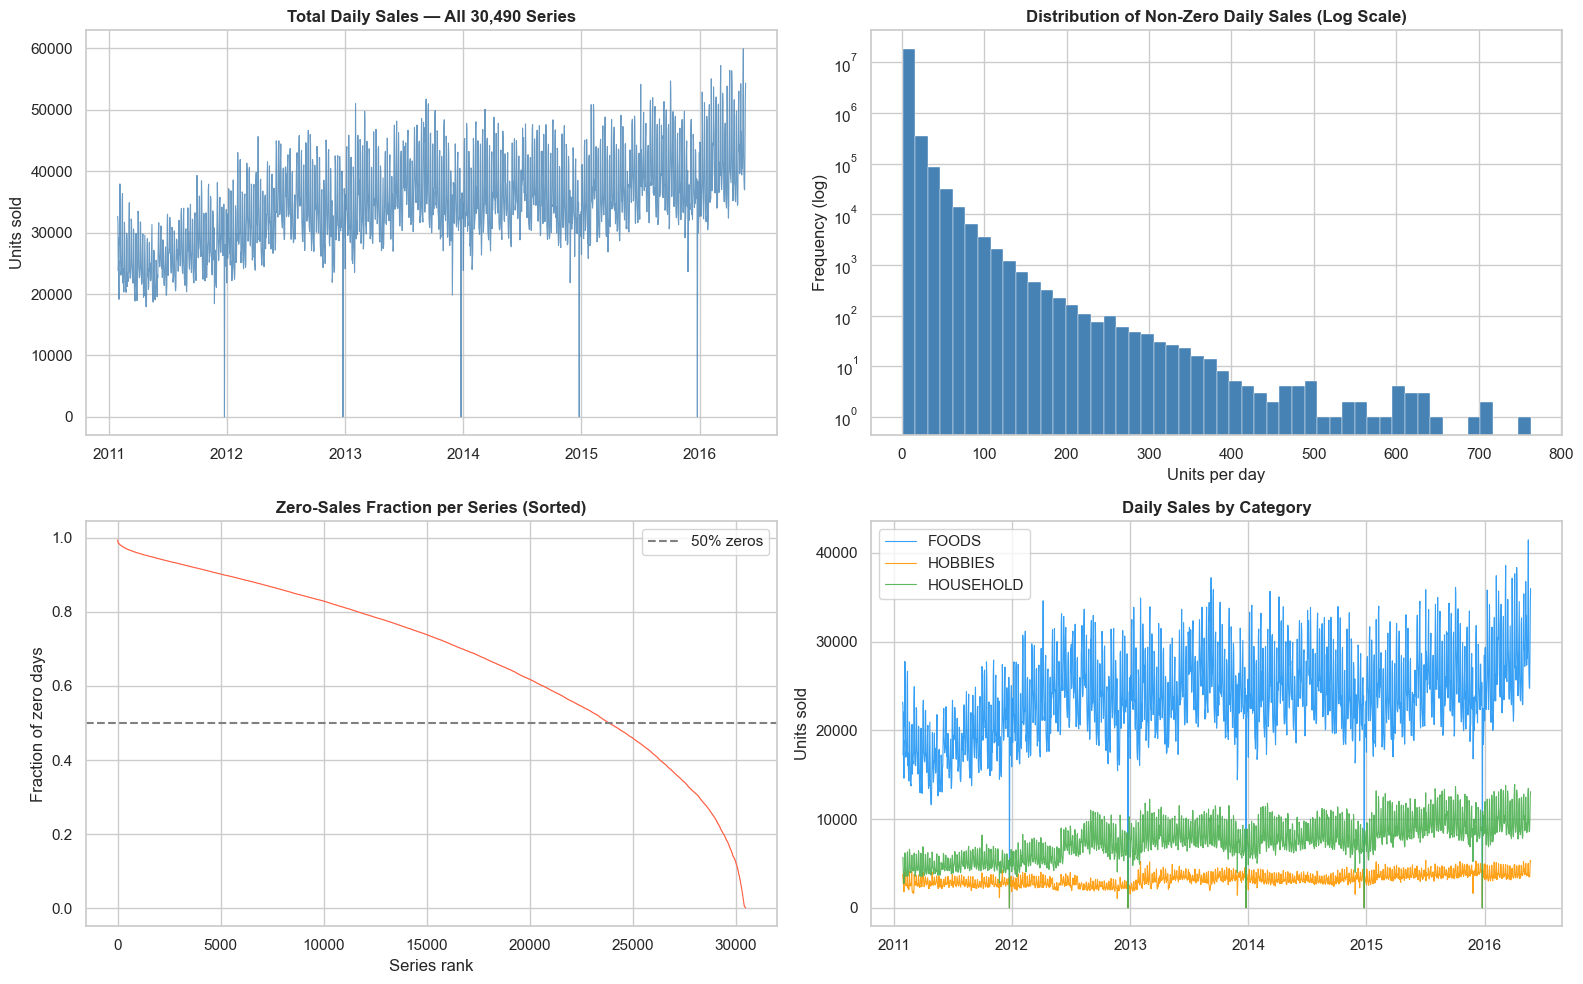

In [9]:
# Total sales over time
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total daily sales time series
ax = axes[0, 0]
ax.plot(dates, daily_total, linewidth=0.8, color='steelblue', alpha=0.8)
ax.set_title('Total Daily Sales — All 30,490 Series', fontweight='bold')
ax.set_ylabel('Units sold')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Sales histogram (log scale)
ax = axes[0, 1]
flat_nonzero = sales_matrix[sales_matrix > 0].flatten()
ax.hist(flat_nonzero, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_title('Distribution of Non-Zero Daily Sales (Log Scale)', fontweight='bold')
ax.set_xlabel('Units per day')
ax.set_ylabel('Frequency (log)')

# Zero fraction per series (sorted)
ax = axes[1, 0]
zero_frac = (sales_matrix == 0).mean(axis=1)
ax.plot(sorted(zero_frac, reverse=True), linewidth=0.8, color='tomato')
ax.axhline(0.5, linestyle='--', color='gray', label='50% zeros')
ax.set_title('Zero-Sales Fraction per Series (Sorted)', fontweight='bold')
ax.set_xlabel('Series rank')
ax.set_ylabel('Fraction of zero days')
ax.legend()

# Category-level sales over time
ax = axes[1, 1]
colors = {'FOODS': '#2196F3', 'HOBBIES': '#FF9800', 'HOUSEHOLD': '#4CAF50'}
for cat, color in colors.items():
    mask = train_eval['cat_id'] == cat
    cat_daily = train_eval.loc[mask, day_cols].values.sum(axis=0)
    ax.plot(dates, cat_daily, linewidth=0.8, label=cat, color=color, alpha=0.9)
ax.set_title('Daily Sales by Category', fontweight='bold')
ax.set_ylabel('Units sold')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../reports/fig_02_sales_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

In [10]:
# Top/bottom items by total sales
total_by_item = train_eval[day_cols].sum(axis=1)
train_eval_meta = train_eval[id_cols].copy()
train_eval_meta['total_sales'] = total_by_item

print('Top 10 best-selling items:')
print(train_eval_meta.nlargest(10, 'total_sales')[['item_id', 'store_id', 'cat_id', 'total_sales']].to_string(index=False))
print('\nBottom 10 worst-selling items:')
print(train_eval_meta.nsmallest(10, 'total_sales')[['item_id', 'store_id', 'cat_id', 'total_sales']].to_string(index=False))

Top 10 best-selling items:
    item_id store_id cat_id  total_sales
FOODS_3_090     CA_3  FOODS       253859
FOODS_3_586     TX_2  FOODS       195120
FOODS_3_586     TX_3  FOODS       151862
FOODS_3_586     CA_3  FOODS       136269
FOODS_3_090     CA_1  FOODS       128855
FOODS_3_090     WI_3  FOODS       123500
FOODS_3_090     TX_2  FOODS       121275
FOODS_3_090     TX_3  FOODS       116773
FOODS_3_252     TX_2  FOODS       115613
FOODS_3_586     TX_1  FOODS       114010

Bottom 10 worst-selling items:
        item_id store_id    cat_id  total_sales
    FOODS_3_778     CA_2     FOODS           15
    FOODS_2_057     WI_2     FOODS           16
  HOBBIES_1_170     WI_3   HOBBIES           16
    FOODS_2_071     TX_3     FOODS           18
HOUSEHOLD_1_378     CA_1 HOUSEHOLD           23
HOUSEHOLD_1_020     CA_3 HOUSEHOLD           23
HOUSEHOLD_2_216     CA_4 HOUSEHOLD           23
HOUSEHOLD_1_336     CA_3 HOUSEHOLD           24
HOUSEHOLD_2_307     CA_4 HOUSEHOLD           24
    FOODS_

## 3.3 Seasonality Analysis

In [11]:
# Build daily total sales with calendar features
daily_df = pd.DataFrame({'date': pd.to_datetime(dates), 'total_sales': daily_total})
daily_df = daily_df.merge(cal[['date','weekday','wday','month','year',
                                'event_name_1','event_type_1',
                                'snap_CA','snap_TX','snap_WI']], on='date', how='left')
daily_df['snap_any'] = daily_df[['snap_CA','snap_TX','snap_WI']].max(axis=1)
daily_df['dow'] = daily_df['date'].dt.dayofweek  # 0=Mon
print(daily_df.shape)
daily_df.head(3)

(1941, 13)


,date,total_sales,weekday,wday,month,year,event_name_1,event_type_1,snap_CA,snap_TX,snap_WI,snap_any,dow
0,2011-01-29,32631,Saturday,1,1,2011,NaN,NaN,0,0,0,0,5
1,2011-01-30,31749,Sunday,2,1,2011,NaN,NaN,0,0,0,0,6
2,2011-01-31,23783,Monday,3,1,2011,NaN,NaN,0,0,0,0,0


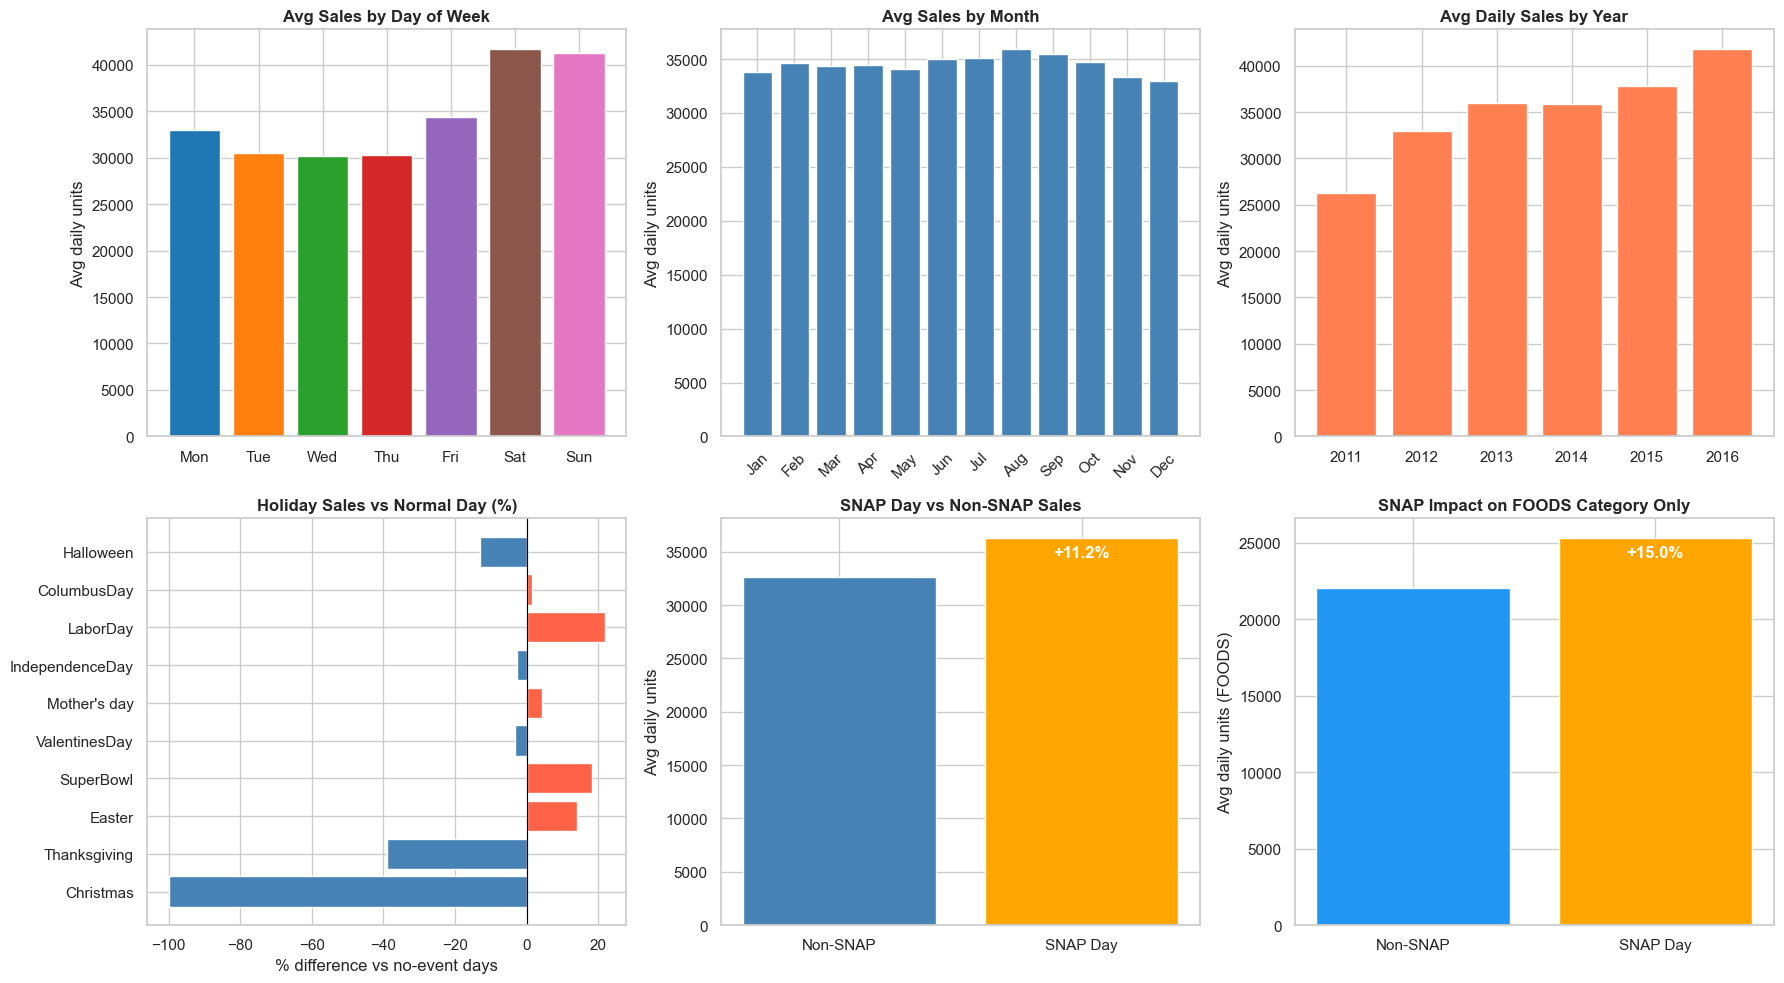


SNAP impact (all categories): +11.2%
SNAP impact (FOODS only):     +15.0%


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Weekly seasonality
ax = axes[0, 0]
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = daily_df.groupby('weekday')['total_sales'].mean().reindex(dow_order)
ax.bar(range(7), dow_sales.values, color=sns.color_palette('tab10', 7))
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in dow_order])
ax.set_title('Avg Sales by Day of Week', fontweight='bold')
ax.set_ylabel('Avg daily units')

# Monthly seasonality
ax = axes[0, 1]
month_sales = daily_df.groupby('month')['total_sales'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.bar(range(1, 13), month_sales.values, color='steelblue')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=45)
ax.set_title('Avg Sales by Month', fontweight='bold')
ax.set_ylabel('Avg daily units')

# Yearly trend
ax = axes[0, 2]
year_sales = daily_df.groupby('year')['total_sales'].mean()
ax.bar(year_sales.index.astype(str), year_sales.values, color='coral')
ax.set_title('Avg Daily Sales by Year', fontweight='bold')
ax.set_ylabel('Avg daily units')

# Holiday impact
ax = axes[1, 0]
major_events = ['Christmas', 'Thanksgiving', 'Easter', 'SuperBowl',
                'ValentinesDay', "Mother's day", 'IndependenceDay',
                'LaborDay', 'ColumbusDay', 'Halloween']
event_sales = []
for evt in major_events:
    mask = daily_df['event_name_1'] == evt
    if mask.sum() > 0:
        event_sales.append((evt, daily_df.loc[mask, 'total_sales'].mean()))
no_event_avg = daily_df.loc[daily_df['event_name_1'].isna(), 'total_sales'].mean()
event_sales_df = pd.DataFrame(event_sales, columns=['event', 'avg_sales'])
event_sales_df['pct_vs_normal'] = 100 * (event_sales_df['avg_sales'] / no_event_avg - 1)
colors_ev = ['tomato' if x > 0 else 'steelblue' for x in event_sales_df['pct_vs_normal']]
ax.barh(event_sales_df['event'], event_sales_df['pct_vs_normal'], color=colors_ev)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Holiday Sales vs Normal Day (%)', fontweight='bold')
ax.set_xlabel('% difference vs no-event days')

# SNAP day impact
ax = axes[1, 1]
snap_comp = daily_df.groupby('snap_any')['total_sales'].mean()
labels = ['Non-SNAP', 'SNAP Day']
ax.bar(labels, snap_comp.values, color=['steelblue', 'orange'])
ax.set_title('SNAP Day vs Non-SNAP Sales', fontweight='bold')
ax.set_ylabel('Avg daily units')
pct_diff = 100 * (snap_comp[1] / snap_comp[0] - 1)
ax.text(1, snap_comp[1] * 0.98, f'+{pct_diff:.1f}%', ha='center', va='top',
        color='white', fontweight='bold', fontsize=12)

# FOODS-only SNAP impact (most relevant)
ax = axes[1, 2]
foods_mask = train_eval['cat_id'] == 'FOODS'
foods_daily = train_eval.loc[foods_mask, day_cols].values.sum(axis=0)
foods_df = pd.DataFrame({'date': pd.to_datetime(dates), 'foods_sales': foods_daily})
foods_df = foods_df.merge(daily_df[['date','snap_any']], on='date')
foods_snap = foods_df.groupby('snap_any')['foods_sales'].mean()
ax.bar(['Non-SNAP', 'SNAP Day'], foods_snap.values, color=['#2196F3', 'orange'])
ax.set_title('SNAP Impact on FOODS Category Only', fontweight='bold')
ax.set_ylabel('Avg daily units (FOODS)')
pct_foods = 100 * (foods_snap[1] / foods_snap[0] - 1)
ax.text(1, foods_snap[1] * 0.98, f'+{pct_foods:.1f}%', ha='center', va='top',
        color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/fig_03_seasonality.png', bbox_inches='tight', dpi=100)
plt.show()
print(f'\nSNAP impact (all categories): +{pct_diff:.1f}%')
print(f'SNAP impact (FOODS only):     +{pct_foods:.1f}%')

## 3.4 Price-Sales Relationship

In [13]:
# Melt sales to long format (sample to manage memory)
# Sample 500 series to create price-sales scatter
np.random.seed(42)
sampled_ids = train_eval['id'].sample(500).values
sample_sales = train_eval[train_eval['id'].isin(sampled_ids)][id_cols + day_cols]

# Melt
sample_long = sample_sales.melt(id_vars=id_cols, var_name='d', value_name='sales')
sample_long = sample_long.merge(cal[['d','date','wm_yr_wk']], on='d', how='left')
sample_long = sample_long.merge(prices, on=['store_id','item_id','wm_yr_wk'], how='left')
sample_long = sample_long.dropna(subset=['sell_price'])
print(f'Sample long format: {sample_long.shape}')
print(sample_long[['item_id','store_id','d','sales','sell_price']].head(3))

Sample long format: (749475, 11)
           item_id store_id    d  sales  sell_price
0    HOBBIES_1_100     CA_1  d_1      1      10.000
2    HOBBIES_1_221     CA_1  d_1      0       2.000
8  HOUSEHOLD_1_059     CA_1  d_1      0       2.970


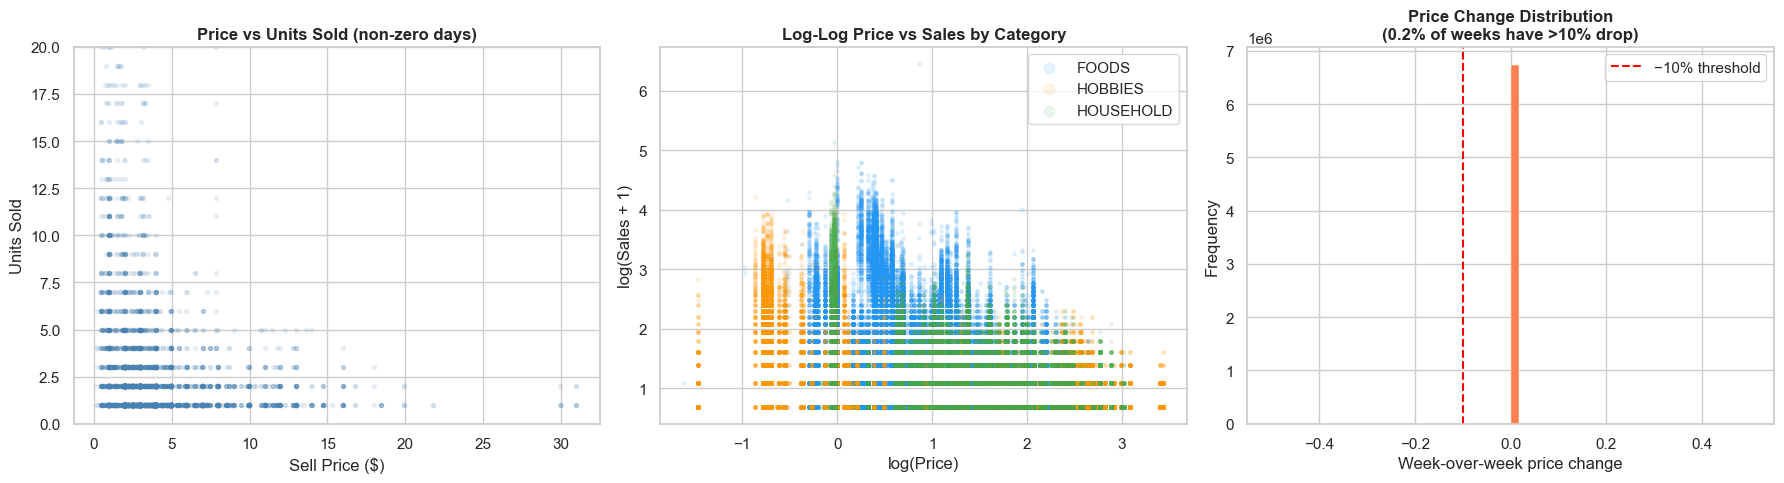

Weeks with price drop >10%: 0.2%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price vs sales scatter (5000 points)
ax = axes[0]
scatter_sample = sample_long[sample_long['sales'] > 0].sample(min(5000, len(sample_long)))
ax.scatter(scatter_sample['sell_price'], scatter_sample['sales'],
           alpha=0.1, s=8, color='steelblue')
ax.set_xlabel('Sell Price ($)')
ax.set_ylabel('Units Sold')
ax.set_title('Price vs Units Sold (non-zero days)', fontweight='bold')
ax.set_ylim(0, 20)

# Price elasticity by category (log-log)
ax = axes[1]
for cat, color in colors.items():
    cat_data = sample_long[(sample_long['cat_id'] == cat) & (sample_long['sales'] > 0)]
    if len(cat_data) > 100:
        ax.scatter(np.log(cat_data['sell_price']),
                   np.log(cat_data['sales'] + 1),
                   alpha=0.1, s=6, label=cat, color=color)
ax.set_xlabel('log(Price)')
ax.set_ylabel('log(Sales + 1)')
ax.set_title('Log-Log Price vs Sales by Category', fontweight='bold')
ax.legend(markerscale=3)

# Promotion detection (price drops)
ax = axes[2]
# For each item-store, detect price drops > 10% as promotions
prices_sorted = prices.sort_values(['store_id','item_id','wm_yr_wk'])
prices_sorted['price_pct_change'] = prices_sorted.groupby(['store_id','item_id'])['sell_price'].pct_change()
promo_mask = prices_sorted['price_pct_change'] < -0.10
promo_pct = 100 * promo_mask.sum() / len(prices_sorted)
ax.hist(prices_sorted['price_pct_change'].dropna().clip(-0.5, 0.5),
        bins=60, color='coral', edgecolor='white', linewidth=0.3)
ax.axvline(-0.1, color='red', linestyle='--', label='−10% threshold')
ax.set_xlabel('Week-over-week price change')
ax.set_ylabel('Frequency')
ax.set_title(f'Price Change Distribution\n({promo_pct:.1f}% of weeks have >10% drop)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/fig_04_price_sales.png', bbox_inches='tight', dpi=100)
plt.show()
print(f'Weeks with price drop >10%: {promo_pct:.1f}%')

## 3.5 Hierarchical Aggregation

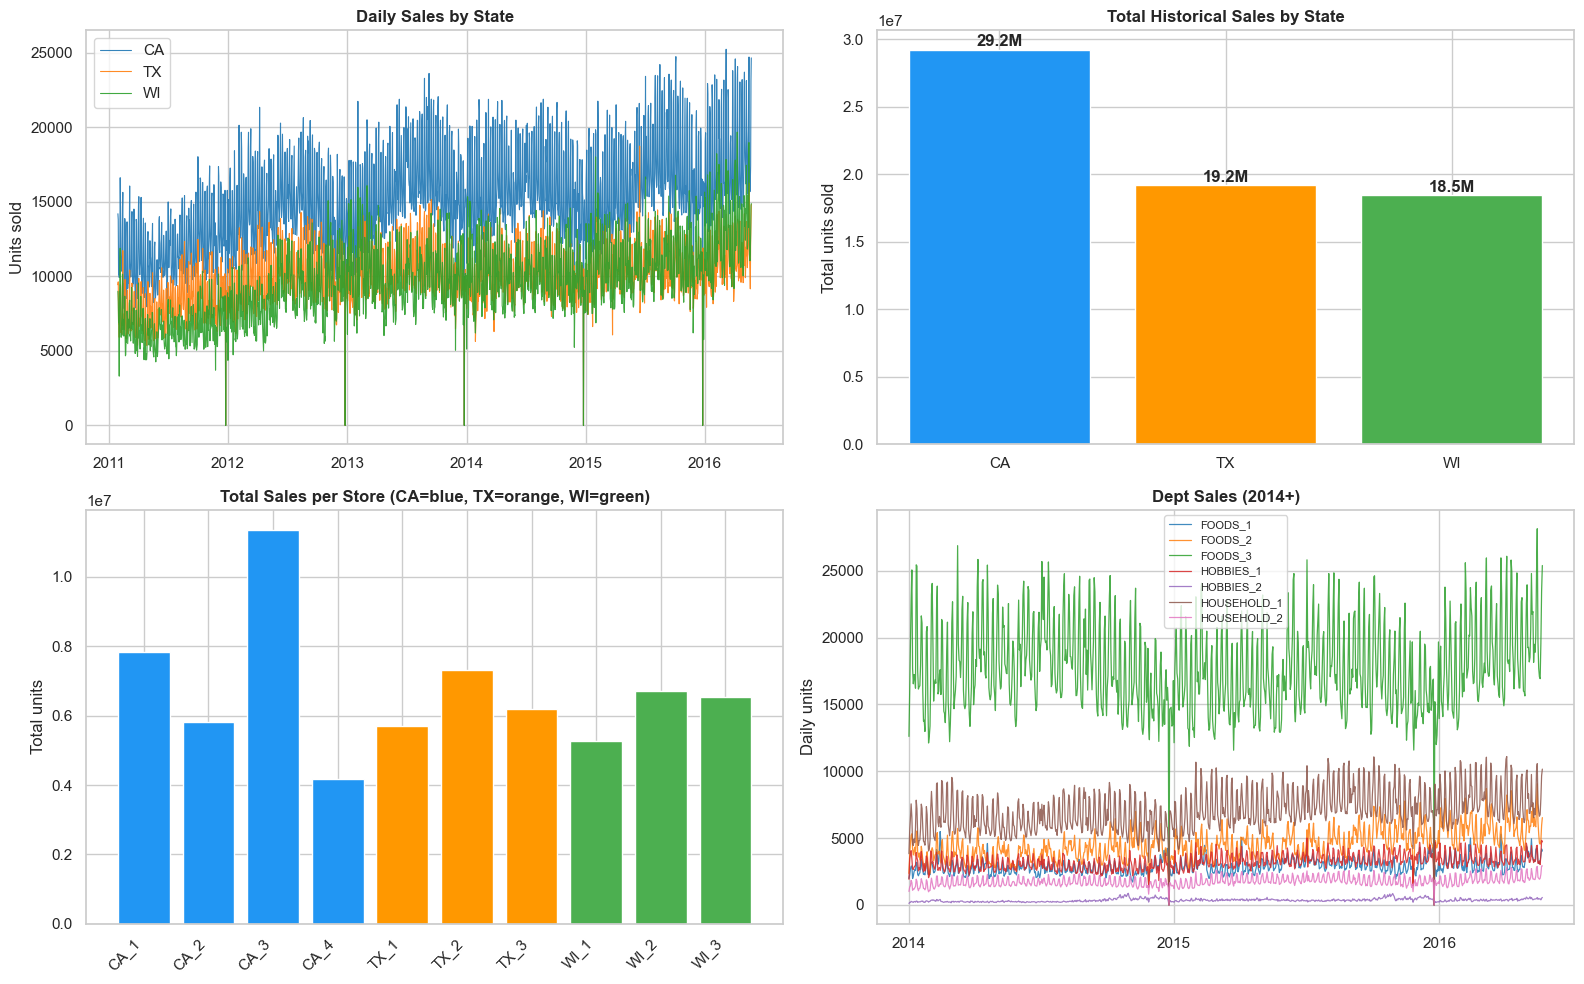

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total sales by state
ax = axes[0, 0]
for state in ['CA', 'TX', 'WI']:
    mask = train_eval['state_id'] == state
    state_daily = train_eval.loc[mask, day_cols].values.sum(axis=0)
    ax.plot(dates, state_daily, linewidth=0.8, label=state, alpha=0.9)
ax.set_title('Daily Sales by State', fontweight='bold')
ax.set_ylabel('Units sold')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# State total comparison
ax = axes[0, 1]
state_totals = {s: train_eval.loc[train_eval['state_id'] == s, day_cols].values.sum()
                for s in ['CA', 'TX', 'WI']}
ax.bar(state_totals.keys(), state_totals.values(), color=['#2196F3','#FF9800','#4CAF50'])
ax.set_title('Total Historical Sales by State', fontweight='bold')
ax.set_ylabel('Total units sold')
for i, (k, v) in enumerate(state_totals.items()):
    ax.text(i, v * 1.01, f'{v/1e6:.1f}M', ha='center', fontweight='bold')

# Sales by store within each state
ax = axes[1, 0]
store_totals = {}
for store in sorted(train_eval['store_id'].unique()):
    mask = train_eval['store_id'] == store
    store_totals[store] = train_eval.loc[mask, day_cols].values.sum()
stores = list(store_totals.keys())
totals = list(store_totals.values())
store_colors = ['#2196F3' if 'CA' in s else '#FF9800' if 'TX' in s else '#4CAF50' for s in stores]
ax.bar(range(len(stores)), totals, color=store_colors)
ax.set_xticks(range(len(stores)))
ax.set_xticklabels(stores, rotation=45, ha='right')
ax.set_title('Total Sales per Store (CA=blue, TX=orange, WI=green)', fontweight='bold')
ax.set_ylabel('Total units')

# Department-level sales over time (last 2 years for clarity)
ax = axes[1, 1]
last_2yr_mask = [d for d, dt in zip(day_cols, dates) if dt is not None and pd.Timestamp(dt) >= pd.Timestamp('2014-01-01')]
last_2yr_dates = [day_to_date.get(d) for d in last_2yr_mask]
dept_palette = sns.color_palette('tab10', n_colors=7)
for i, dept in enumerate(sorted(train_eval['dept_id'].unique())):
    mask = train_eval['dept_id'] == dept
    dept_daily = train_eval.loc[mask, last_2yr_mask].values.sum(axis=0)
    ax.plot(last_2yr_dates, dept_daily, linewidth=0.9,
            label=dept, color=dept_palette[i], alpha=0.85)
ax.set_title('Dept Sales (2014+)', fontweight='bold')
ax.set_ylabel('Daily units')
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../reports/fig_05_hierarchical.png', bbox_inches='tight', dpi=100)
plt.show()

## 3.6 Time Series Characteristics

In [16]:
# ADF stationarity test on 100 randomly sampled series
np.random.seed(0)
sample_indices = np.random.choice(len(train_eval), 100, replace=False)
adf_results = []
for idx in sample_indices:
    series = train_eval.iloc[idx][day_cols].values.astype(float)
    # Only test if series has sufficient non-zero values
    if (series > 0).sum() < 30:
        continue
    try:
        result = adfuller(series, autolag='AIC')
        adf_results.append({'adf_stat': result[0], 'p_value': result[1],
                             'is_stationary': result[1] < 0.05,
                             'item_id': train_eval.iloc[idx]['item_id'],
                             'cat_id': train_eval.iloc[idx]['cat_id']})
    except Exception:
        pass

adf_df = pd.DataFrame(adf_results)
pct_stationary = 100 * adf_df['is_stationary'].mean()
print(f'ADF test on {len(adf_df)} series:')
print(f'  Stationary (p<0.05): {pct_stationary:.1f}%')
print(f'\nBy category:')
print(adf_df.groupby('cat_id')['is_stationary'].mean().mul(100).round(1).to_string())

ADF test on 99 series:
  Stationary (p<0.05): 89.9%

By category:
cat_id
FOODS        93.800
HOBBIES     100.000
HOUSEHOLD    80.600


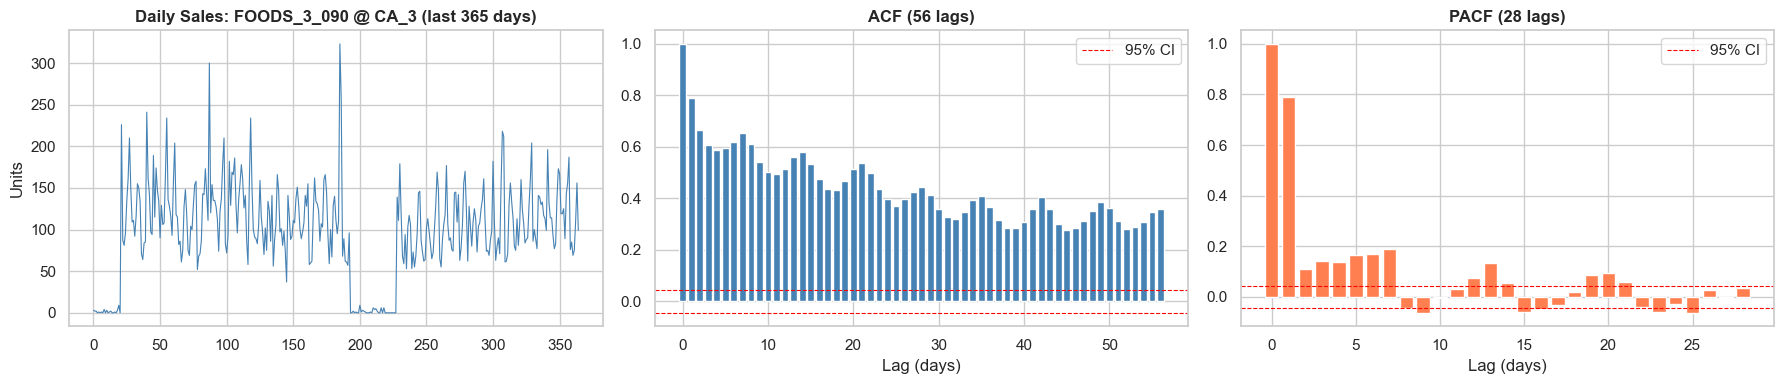

In [17]:
# ACF/PACF for a representative FOODS item
# Pick best-selling FOODS item
top_foods_idx = train_eval_meta[train_eval_meta['cat_id'] == 'FOODS']['total_sales'].idxmax()
top_series = train_eval.loc[top_foods_idx, day_cols].values.astype(float)
top_item_id = train_eval.loc[top_foods_idx, 'item_id']
top_store_id = train_eval.loc[top_foods_idx, 'store_id']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Raw series
ax = axes[0]
ax.plot(top_series[-365:], linewidth=0.8, color='steelblue')
ax.set_title(f'Daily Sales: {top_item_id} @ {top_store_id} (last 365 days)', fontweight='bold')
ax.set_ylabel('Units')

# ACF
ax = axes[1]
acf_vals = acf(top_series, nlags=56, fft=True)
ax.bar(range(len(acf_vals)), acf_vals, color='steelblue', width=0.8)
ax.axhline(1.96/np.sqrt(len(top_series)), color='red', linestyle='--', linewidth=0.8, label='95% CI')
ax.axhline(-1.96/np.sqrt(len(top_series)), color='red', linestyle='--', linewidth=0.8)
ax.set_title('ACF (56 lags)', fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.legend()

# PACF
ax = axes[2]
pacf_vals = pacf(top_series, nlags=28)
ax.bar(range(len(pacf_vals)), pacf_vals, color='coral', width=0.8)
ax.axhline(1.96/np.sqrt(len(top_series)), color='red', linestyle='--', linewidth=0.8, label='95% CI')
ax.axhline(-1.96/np.sqrt(len(top_series)), color='red', linestyle='--', linewidth=0.8)
ax.set_title('PACF (28 lags)', fontweight='bold')
ax.set_xlabel('Lag (days)')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/fig_06_acf_pacf.png', bbox_inches='tight', dpi=100)
plt.show()

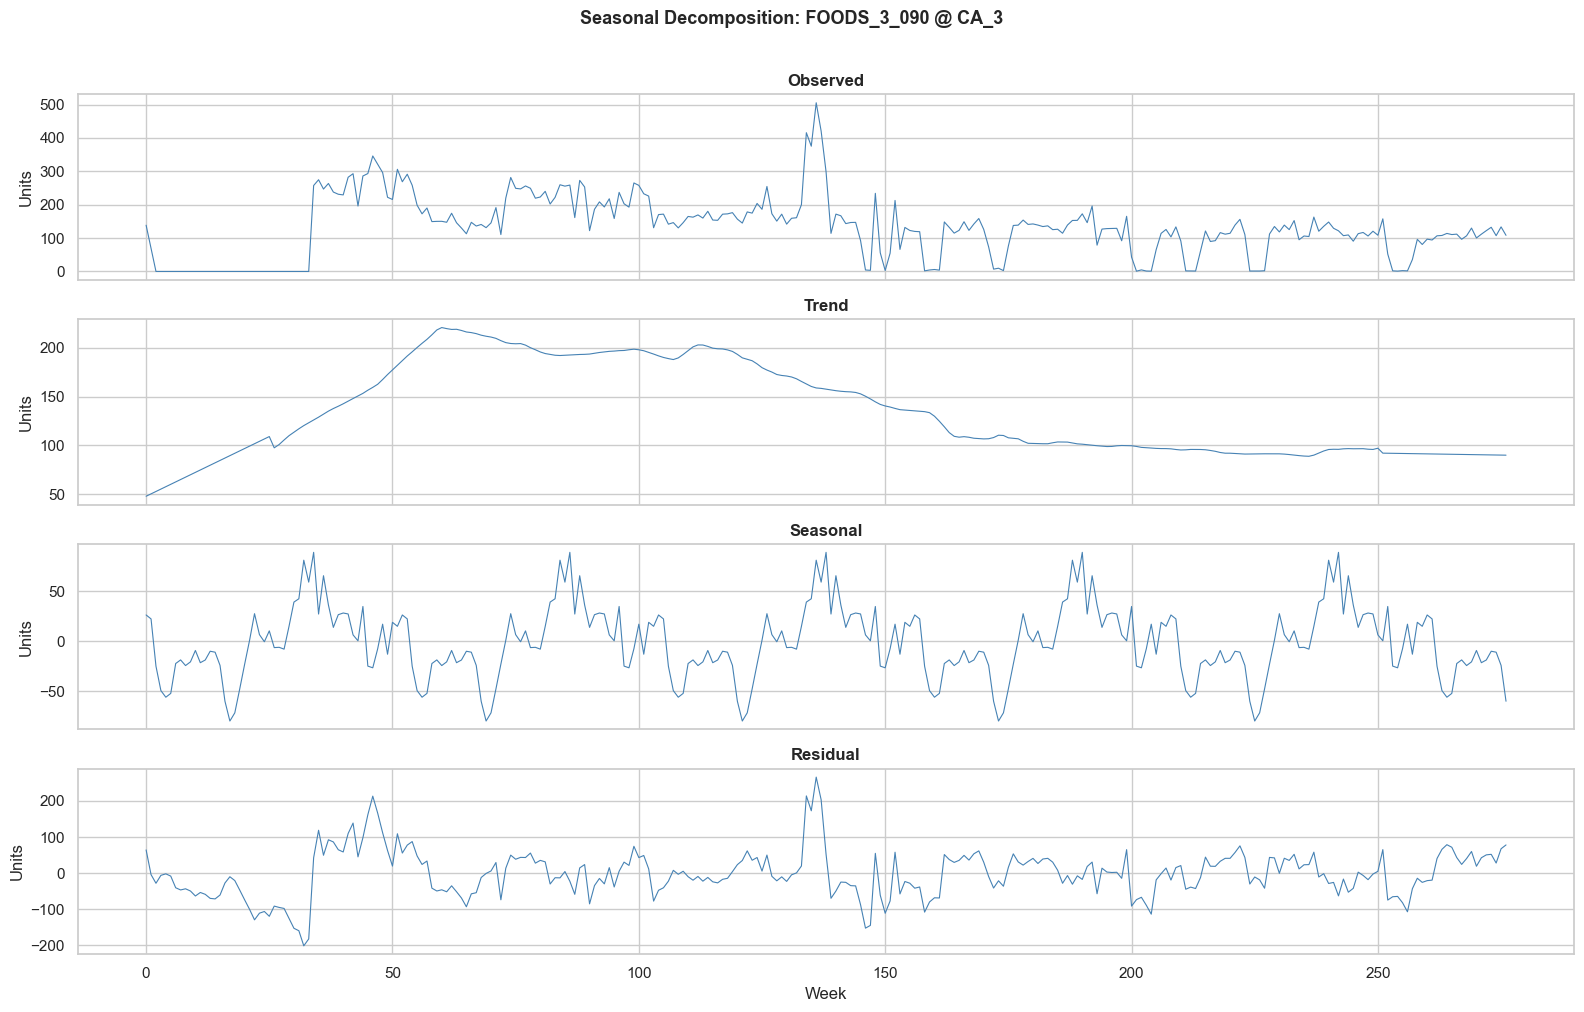

In [18]:
# Trend decomposition for the top FOODS item
from statsmodels.tsa.seasonal import seasonal_decompose

# Use weekly data (aggregate to 7-day blocks) for cleaner decomposition
weekly_series = pd.Series(top_series).rolling(7).mean().dropna()
decomp = seasonal_decompose(weekly_series[::7], model='additive', period=52, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
titles = ['Observed', 'Trend', 'Seasonal', 'Residual']
series_list = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
for ax, title, s in zip(axes, titles, series_list):
    ax.plot(s.values, linewidth=0.8, color='steelblue')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Units')
axes[-1].set_xlabel('Week')
plt.suptitle(f'Seasonal Decomposition: {top_item_id} @ {top_store_id}',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/fig_07_decomposition.png', bbox_inches='tight', dpi=100)
plt.show()

## 3.7 Modeling Implications

In [19]:
# Classify series by demand type
zero_frac_all = (sales_matrix == 0).mean(axis=1)

smooth     = (zero_frac_all < 0.05).sum()
low_inter  = ((zero_frac_all >= 0.05) & (zero_frac_all < 0.30)).sum()
inter      = ((zero_frac_all >= 0.30) & (zero_frac_all < 0.70)).sum()
lumpy      = (zero_frac_all >= 0.70).sum()

print('--- DEMAND TYPE CLASSIFICATION ---')
print(f'Smooth     (<5% zeros)   : {smooth:5d} ({100*smooth/len(zero_frac_all):.1f}%)')
print(f'Low inter  (5-30% zeros) : {low_inter:5d} ({100*low_inter/len(zero_frac_all):.1f}%)')
print(f'Intermittent (30-70%)    : {inter:5d} ({100*inter/len(zero_frac_all):.1f}%)')
print(f'Lumpy/Erratic (>70%)     : {lumpy:5d} ({100*lumpy/len(zero_frac_all):.1f}%)')

# By category
print('\nBy category:')
for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    mask = train_eval['cat_id'] == cat
    cat_zf = zero_frac_all[mask]
    print(f'  {cat:12s}: mean_zero={cat_zf.mean():.2f}, >70%_zero={100*(cat_zf>0.7).mean():.1f}% of series')

--- DEMAND TYPE CLASSIFICATION ---
Smooth     (<5% zeros)   :   184 (0.6%)
Low inter  (5-30% zeros) :  2077 (6.8%)
Intermittent (30-70%)    : 11505 (37.7%)
Lumpy/Erratic (>70%)     : 16724 (54.9%)

By category:
  FOODS       : mean_zero=0.62, >70%_zero=42.5% of series
  HOBBIES     : mean_zero=0.77, >70%_zero=72.6% of series
  HOUSEHOLD   : mean_zero=0.72, >70%_zero=62.2% of series


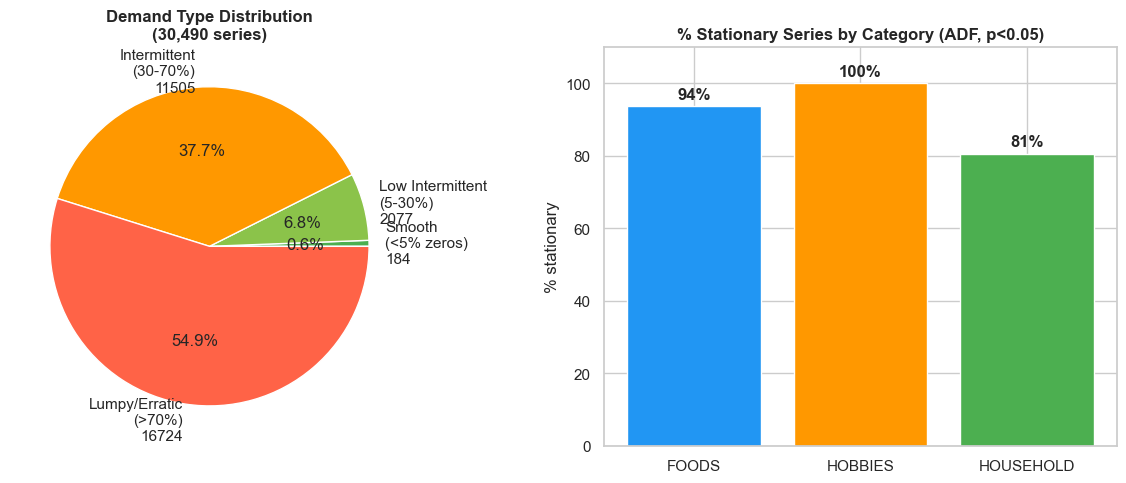

In [20]:
# Demand type pie
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
demand_counts = [smooth, low_inter, inter, lumpy]
demand_labels = [f'Smooth\n(<5% zeros)\n{smooth}',
                 f'Low Intermittent\n(5-30%)\n{low_inter}',
                 f'Intermittent\n(30-70%)\n{inter}',
                 f'Lumpy/Erratic\n(>70%)\n{lumpy}']
ax.pie(demand_counts, labels=demand_labels, autopct='%1.1f%%',
       colors=['#4CAF50','#8BC34A','#FF9800','tomato'])
ax.set_title('Demand Type Distribution\n(30,490 series)', fontweight='bold')

# ADF results by category
ax = axes[1]
if len(adf_df) > 0:
    adf_cat = adf_df.groupby('cat_id')['is_stationary'].mean().mul(100)
    ax.bar(adf_cat.index, adf_cat.values, color=['#2196F3','#FF9800','#4CAF50'])
    ax.set_title('% Stationary Series by Category (ADF, p<0.05)', fontweight='bold')
    ax.set_ylabel('% stationary')
    ax.set_ylim(0, 110)
    for i, (cat, val) in enumerate(adf_cat.items()):
        ax.text(i, val + 2, f'{val:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/fig_08_demand_types.png', bbox_inches='tight', dpi=100)
plt.show()

In [21]:
# Summary stats for the findings document
print('=== KEY STATS FOR EDA FINDINGS DOCUMENT ===')
print(f'Total series            : {len(train_eval):,}')
print(f'Total days of history   : {len(day_cols)}')
print(f'Date range              : {cal.date.min().date()} → {cal.date.max().date()}')
print(f'Unique items            : {train_eval.item_id.nunique():,}')
print(f'Unique stores           : {train_eval.store_id.nunique()}')
print(f'Unique states           : {train_eval.state_id.nunique()}')
print(f'Unique departments      : {train_eval.dept_id.nunique()}')
print(f'Overall zero rate       : {zero_pct:.1f}%')
print(f'Total units sold (eval) : {int(sales_matrix.sum()):,}')
print(f'Stationary series       : {pct_stationary:.1f}%')
print(f'Promo weeks (>10% drop) : {promo_pct:.1f}%')
print(f'SNAP total impact       : +{pct_diff:.1f}%')
print(f'SNAP foods impact       : +{pct_foods:.1f}%')

=== KEY STATS FOR EDA FINDINGS DOCUMENT ===
Total series            : 30,490
Total days of history   : 1941
Date range              : 2011-01-29 → 2016-06-19
Unique items            : 3,049
Unique stores           : 10
Unique states           : 3
Unique departments      : 7
Overall zero rate       : 68.0%
Total units sold (eval) : 66,927,173
Stationary series       : 89.9%
Promo weeks (>10% drop) : 0.2%
SNAP total impact       : +11.2%
SNAP foods impact       : +15.0%


In [22]:
# Save all key findings to a findings dict for the report
findings = {
    'total_series': len(train_eval),
    'history_days': len(day_cols),
    'zero_rate_overall': float(zero_pct),
    'zero_rate_hobbies': float(100 * (train_eval.loc[train_eval.cat_id=='HOBBIES', day_cols].values == 0).mean()),
    'zero_rate_foods': float(100 * (train_eval.loc[train_eval.cat_id=='FOODS', day_cols].values == 0).mean()),
    'zero_rate_household': float(100 * (train_eval.loc[train_eval.cat_id=='HOUSEHOLD', day_cols].values == 0).mean()),
    'pct_stationary': float(pct_stationary),
    'snap_impact_all': float(pct_diff),
    'snap_impact_foods': float(pct_foods),
    'promo_pct': float(promo_pct),
    'lumpy_series': int(lumpy),
    'smooth_series': int(smooth),
}
import json
with open('../reports/eda_stats.json', 'w') as f:
    json.dump(findings, f, indent=2)
print('Stats saved to reports/eda_stats.json')
print(json.dumps(findings, indent=2))

Stats saved to reports/eda_stats.json
{
  "total_series": 30490,
  "history_days": 1941,
  "zero_rate_overall": 67.99776584040612,
  "zero_rate_hobbies": 77.1491658801913,
  "zero_rate_foods": 61.77342243360771,
  "zero_rate_household": 71.60219798280409,
  "pct_stationary": 89.8989898989899,
  "snap_impact_all": 11.183473327553894,
  "snap_impact_foods": 14.96685490351326,
  "promo_pct": 0.24873116555020733,
  "lumpy_series": 16724,
  "smooth_series": 184
}


---
## Summary

Key findings documented in `reports/01_eda_findings.md`.  
All figures saved to `reports/fig_0*.png`.